рактична робота 7
Візуалізація: Figure і Axes, гістограма, boxplot, діаграма розсіювання
Виконавець: Войтович Богдан, IT-32
Варіант: 6 (Чернігів)

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Фіксація генератора для відтворюваності
np.random.seed(6)

# Параметри варіанту 6 — Чернігів
base_sales = 32
base_temp = 0

days = np.arange(1, 31)
weekend = np.isin(days % 7, [6, 0])  # умовні вихідні (6-й і 7-й дні тижня)
# Температура з випадковим відхиленням ±3 градуси
temperature = base_temp + np.random.uniform(-3, 3, size=30).round(1)
# Продажі: базові + випадкова варіація ±4, із підвищенням на вихідні +15-25%
sales = (base_sales + np.random.uniform(-4, 4, size=30)).round()
sales[weekend] = (sales[weekend] * np.random.uniform(1.15, 1.25, size=weekend.sum())).round()

data = pd.DataFrame({
    "День": days,
    "Вихідний": weekend,
    "Температура (°C)": temperature,
    "Продажі (шт.)": sales.astype(int)
})

data.head()


,День,Вихідний,Температура (°C),Продажі (шт.)
0,1,False,2.4,34
1,2,False,-1.0,36
2,3,False,1.9,30
3,4,False,-2.7,33
4,5,False,-2.4,33


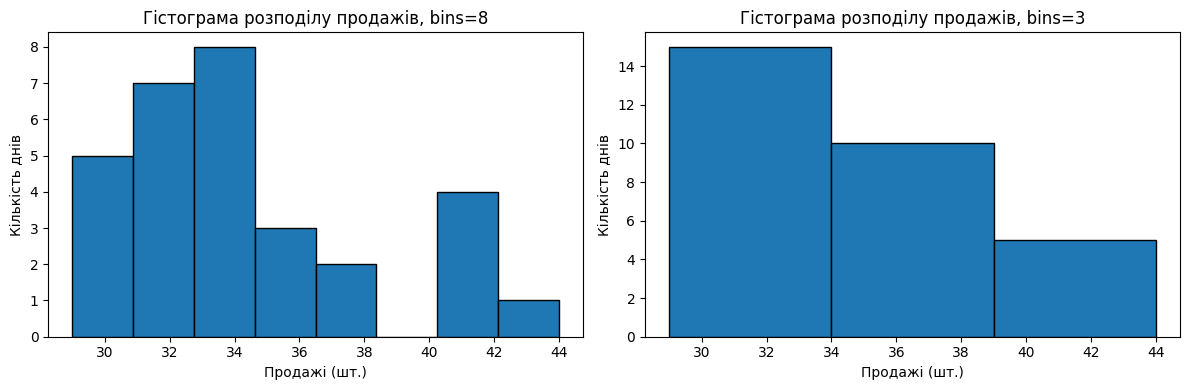

In [52]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Коректна гістограма з 8 інтервалами
axs[0].hist(data["Продажі (шт.)"], bins=8, edgecolor='black')
axs[0].set_xlabel("Продажі (шт.)")
axs[0].set_ylabel("Кількість днів")
axs[0].set_title("Гістограма розподілу продажів, bins=8")

# Гістограма з 3 інтервалами — надто груба
axs[1].hist(data["Продажі (шт.)"], bins=3, edgecolor='black')
axs[1].set_xlabel("Продажі (шт.)")
axs[1].set_ylabel("Кількість днів")
axs[1].set_title("Гістограма розподілу продажів, bins=3")

plt.tight_layout()
plt.show()


/tmp/ipykernel_4877/2128664649.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=["Будні", "Вихідні"])


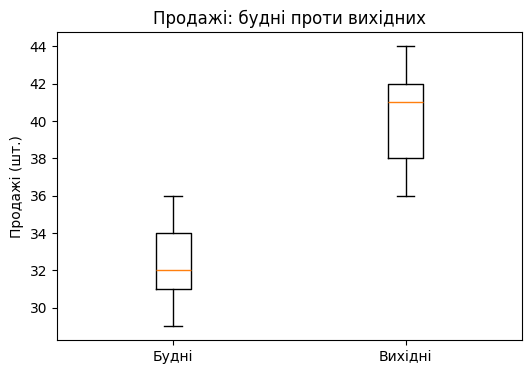

In [53]:
fig, ax = plt.subplots(figsize=(6, 4))

# Групування продажів за вихідними
groups = [data.loc[~data["Вихідний"], "Продажі (шт.)"], data.loc[data["Вихідний"], "Продажі (шт.)"]]
ax.boxplot(groups, labels=["Будні", "Вихідні"])
ax.set_ylabel("Продажі (шт.)")
ax.set_title("Продажі: будні проти вихідних")

plt.show()


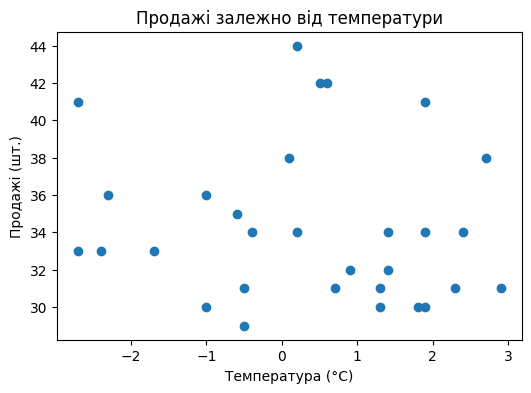

In [54]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(data["Температура (°C)"], data["Продажі (шт.)"])
ax.set_xlabel("Температура (°C)")
ax.set_ylabel("Продажі (шт.)")
ax.set_title("Продажі залежно від температури")

plt.show()


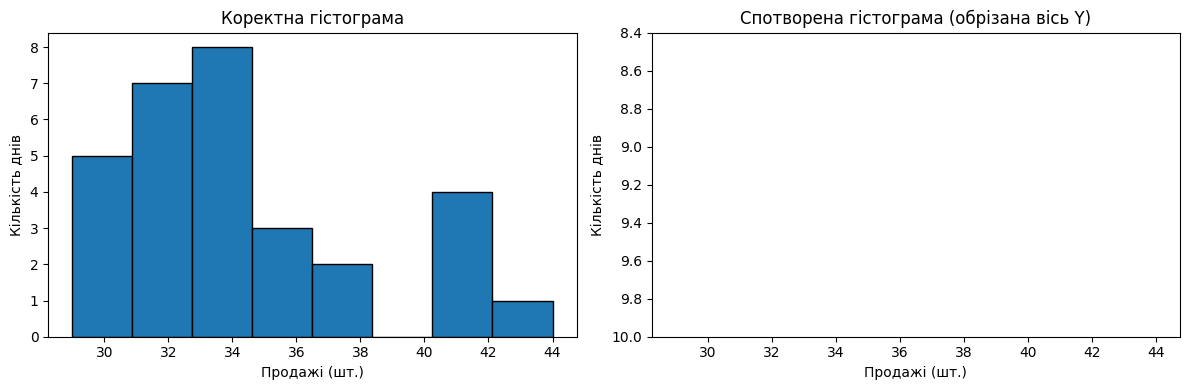

In [55]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Коректна гістограма
axs[0].hist(data["Продажі (шт.)"], bins=8, edgecolor='black')
axs[0].set_xlabel("Продажі (шт.)")
axs[0].set_ylabel("Кількість днів")
axs[0].set_title("Коректна гістограма")

# Спотворена гістограма (обрізаємо вісь Y)
axs[1].hist(data["Продажі (шт.)"], bins=8, edgecolor='black')
axs[1].set_ylim(10, axs[1].get_ylim()[1])  # Обрізка вісі Y піднімає мінімум, перебільшуючи різницю
axs[1].set_xlabel("Продажі (шт.)")
axs[1].set_ylabel("Кількість днів")
axs[1].set_title("Спотворена гістограма (обрізана вісь Y)")

plt.tight_layout()
plt.show()


Контрольні питання (короткі відповіді)
Чому обрізана вісь Y перебільшує різницю?
Бо змінюється масштаб вертикальної осі, і навіть невеликі абсолютні відмінності виглядають значно більшими через стиснення діапазону.

Коли лінійний графік — помилка для категоріальних даних?
Коли дані номінальні або порядкові без природного безперервного порядку, з’єднання точок лінією вводить в оману про послідовність чи безперервність (шкали вимірювання).

Чому підписи осей, одиниці і заголовок — не декор, а частина повідомлення?
Бо вони інформують про зміст даних, контекст і додають розуміння, без них графік може бути неінтерпретованим або неправильно зрозумілим.

Що таке chartjunk і чому він шкодить?
Chartjunk — зайві декоративні елементи (3D-ефекти, яскраві тіні), що відволікають і ускладнюють читання графіка, роблячи його менш зрозумілим.